In [1]:
import sys

In [2]:
import gbtoolbox.bounds as bounds
import gbtoolbox.misc as mt
import gbtoolbox.dft as dft
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy import interpolate
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
print(torch.__version__)
from datetime import datetime
from torch.utils.data import Dataset, DataLoader, TensorDataset

 cupy not imported 
2.5.1


In [3]:
if torch.backends.mps.is_available():
    print("MPS is available!")
else:
    print("MPS is not available.")

MPS is available!


In [4]:
N = 800
mult = 2*2
span = 2
x = (np.random.rand(mult*N).reshape(-1,2)*2-1)*span/2.0
y = np.sin(1*1*np.pi*x[:,0])*np.sin(2*1*np.pi*x[:,1])

let's test quantization

In [5]:
xc = (x*100).astype('int8')
print(xc)
indexing='xy'
grid_info = np.array([[-50, 50,100] for j in np.arange(2)])
ff = [np.arange(grid_info[i,0], grid_info[i,1], (grid_info[i,1]-grid_info[i,0])/grid_info[i,2], dtype='int8') for i in np.arange(grid_info.shape[0])]
ff = np.meshgrid(*ff, indexing=indexing)
dd = len(ff)
NN = ff[0].size
fff = [np.reshape(xt,(NN,1)) for xt in ff]
f = np.hstack(np.array(fff))
print(f)

[[ 50 -75]
 [-42  46]
 [ 19  58]
 ...
 [-81  38]
 [-27  18]
 [ 26 -70]]
[[-50 -50]
 [-49 -50]
 [-48 -50]
 ...
 [ 47  49]
 [ 48  49]
 [ 49  49]]


In [6]:
print(f.shape,xc.shape)
xcf = np.matmul(xc,f.T)
cc = np.cos(xcf*np.pi/100)
sc = np.sin(xcf*np.pi/100)
print(cc)
print(sc)
cyc = np.matmul(y,cc)
syc = np.matmul(y,sc)
cyc + 1j*syc

(10000, 2) (1600, 2)
[[ 0.58778525  0.80901699 -0.58778525 ...  0.15643447  0.98768834
  -0.15643447]
 [-0.18738131  0.90482705  0.63742399 ...  0.72896863  0.84432793
  -0.30901699]
 [ 0.95105652  0.96029369  0.63742399 ... -0.98768834 -0.90482705
  -0.50904142]
 ...
 [-0.99802673  0.79015501 -0.30901699 ... -0.99556196  0.77051324
  -0.27899111]
 [-0.36812455 -0.94088077 -0.87630668 ... -0.70710678 -0.99802673
  -0.61290705]
 [-0.9921147  -0.77051324 -0.06279052 ... -0.9921147  -0.77051324
  -0.96858316]]
[[-0.80901699  0.58778525  0.80901699 ... -0.98768834  0.15643447
   0.98768834]
 [ 0.98228725  0.42577929 -0.77051324 ...  0.68454711 -0.53582679
  -0.95105652]
 [-0.30901699  0.27899111  0.77051324 ...  0.15643447 -0.42577929
  -0.86074203]
 ...
 [-0.06279052  0.61290705 -0.95105652 ... -0.09410831  0.63742399
  -0.96029369]
 [-0.92977649 -0.33873792  0.48175367 ... -0.70710678  0.06279052
   0.79015501]
 [ 0.12533323 -0.63742399 -0.99802673 ...  0.12533323 -0.63742399
   0.248689

array([10.80839047 +1.15309825j,  3.50961936 +8.18480364j,
        1.45233156-13.08231135j, ..., -2.53296092 +6.61305229j,
        8.38268467 +0.14744729j,  1.74777176 +8.84159914j])

In [7]:
print(np.min(cyc))
print(cyc.shape)

-324.529653584053
(10000,)


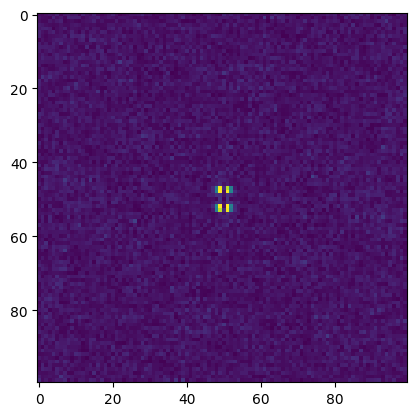

In [8]:
plt.imshow(np.abs(cyc + 1j*syc).reshape(100,100))

That looks reasonable.

Text(0, 0.5, 'y')

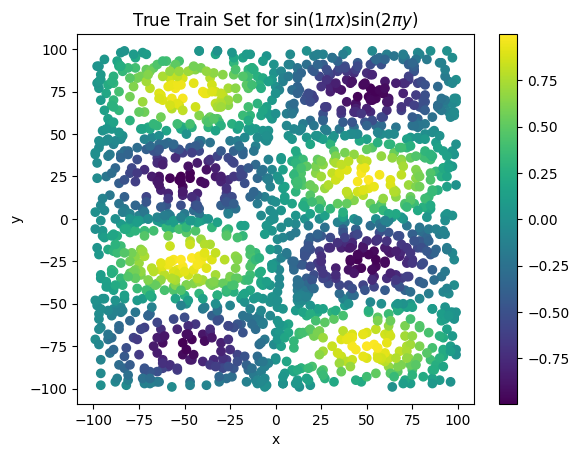

In [9]:
plt.scatter(xc[:,0], xc[:,1], c=y)
plt.colorbar()
plt.title('True Train Set for $\sin(1\pi x)\sin(2\pi y)$')
plt.xlabel('x')
plt.ylabel('y')

In [10]:
xc = (x*128).astype('int8')
print(xc)
indexing='xy'
grid_info = np.array([[-16, 16,32] for j in np.arange(2)])
ff = [np.arange(grid_info[i,0], grid_info[i,1], (grid_info[i,1]-grid_info[i,0])/grid_info[i,2], dtype='int8') for i in np.arange(grid_info.shape[0])]
ff = np.meshgrid(*ff, indexing=indexing)
dd = len(ff)
NN = ff[0].size
fff = [np.reshape(xt,(NN,1)) for xt in ff]
f = np.hstack(np.array(fff))
print(f)

[[  65  -96]
 [ -54   59]
 [  24   74]
 ...
 [-104   49]
 [ -35   24]
 [  33  -89]]
[[-16 -16]
 [-15 -16]
 [-14 -16]
 ...
 [ 13  15]
 [ 14  15]
 [ 15  15]]


In [11]:
print(f.shape,xc.shape,f.dtype,xc.dtype)
xcf = np.matmul(xc,f.T)
cc = np.cos(xcf*np.pi/128)
sc = np.sin(xcf*np.pi/128)
print(cc)
print(sc)
cyc = np.matmul(y,cc)
syc = np.matmul(y,sc)
cyc + 1j*syc

(1024, 2) (1600, 2) int8 int8
[[ 0.92387953  0.35989504 -0.94154407 ... -0.44961133  0.90398929
   0.40524131]
 [-0.38268343 -0.98917651 -0.09801714 ... -0.21910124 -0.99969882
  -0.26671276]
 [ 0.70710678  0.98078528  0.92387953 ... -0.94154407 -0.5956993
  -0.04906767]
 ...
 [-0.92387953  0.98078528 -0.70710678 ... -0.84485357  0.40524131
   0.17096189]
 [-0.38268343 -0.94952818 -0.85772861 ... -0.68954054 -0.99879546
  -0.61523159]
 [-1.         -0.68954054  0.04906767 ... -0.97003125 -0.84485357
  -0.19509032]]
[[-3.82683432e-01  9.32992799e-01  3.36889853e-01 ... -8.93224301e-01
  -4.27555093e-01  9.14209756e-01]
 [-9.23879533e-01  1.46730474e-01  9.95184727e-01 ... -9.75702130e-01
  -2.45412285e-02  9.63776066e-01]
 [-7.07106781e-01 -1.95090322e-01  3.82683432e-01 ... -3.36889853e-01
  -8.03207531e-01 -9.98795456e-01]
 ...
 [ 3.82683432e-01  1.95090322e-01 -7.07106781e-01 ... -5.34997620e-01
   9.14209756e-01 -9.85277642e-01]
 [-9.23879533e-01 -3.13681740e-01  5.14102744e-01 ... 

array([ -8.13131669 -3.58124177j,  11.17189025-24.94574702j,
       -14.38548347-10.87183456j, ...,  -4.62452177+28.56696911j,
         2.9336529  -3.96460136j,  -7.8102217  -4.53049862j])

In [12]:
print(np.min(cyc))
print(cyc.shape)

-406.61113278509504
(1024,)


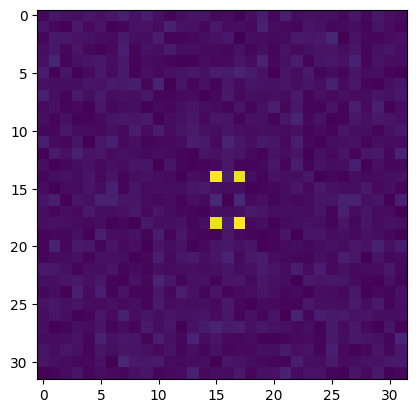

In [13]:
plt.imshow(np.abs(cyc + 1j*syc).reshape(32,32))

Also looks reasonable.

Text(0, 0.5, 'y')

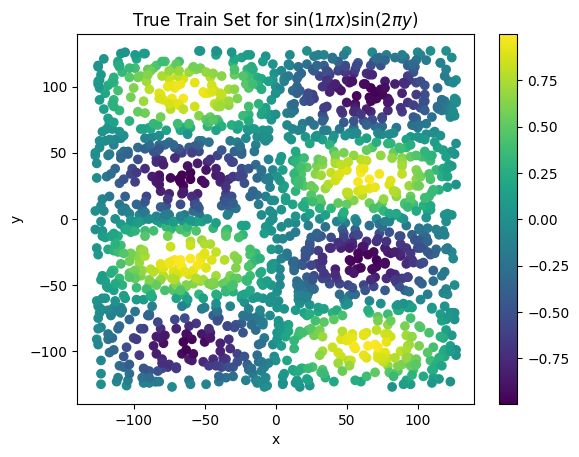

In [14]:
plt.scatter(xc[:,0], xc[:,1], c=y)
plt.colorbar()
plt.title('True Train Set for $\sin(1\pi x)\sin(2\pi y)$')
plt.xlabel('x')
plt.ylabel('y')

In [15]:
xc = (x*8).astype('int8')
print(xc)
indexing='xy'
grid_info = np.array([[-8, 8,16] for j in np.arange(2)])
ff = [np.arange(grid_info[i,0], grid_info[i,1], (grid_info[i,1]-grid_info[i,0])/grid_info[i,2], dtype='int8') for i in np.arange(grid_info.shape[0])]
ff = np.meshgrid(*ff, indexing=indexing)
dd = len(ff)
NN = ff[0].size
fff = [np.reshape(xt,(NN,1)) for xt in ff]
f = np.hstack(np.array(fff))
print(f)

[[ 4 -6]
 [-3  3]
 [ 1  4]
 ...
 [-6  3]
 [-2  1]
 [ 2 -5]]
[[-8 -8]
 [-7 -8]
 [-6 -8]
 [-5 -8]
 [-4 -8]
 [-3 -8]
 [-2 -8]
 [-1 -8]
 [ 0 -8]
 [ 1 -8]
 [ 2 -8]
 [ 3 -8]
 [ 4 -8]
 [ 5 -8]
 [ 6 -8]
 [ 7 -8]
 [-8 -7]
 [-7 -7]
 [-6 -7]
 [-5 -7]
 [-4 -7]
 [-3 -7]
 [-2 -7]
 [-1 -7]
 [ 0 -7]
 [ 1 -7]
 [ 2 -7]
 [ 3 -7]
 [ 4 -7]
 [ 5 -7]
 [ 6 -7]
 [ 7 -7]
 [-8 -6]
 [-7 -6]
 [-6 -6]
 [-5 -6]
 [-4 -6]
 [-3 -6]
 [-2 -6]
 [-1 -6]
 [ 0 -6]
 [ 1 -6]
 [ 2 -6]
 [ 3 -6]
 [ 4 -6]
 [ 5 -6]
 [ 6 -6]
 [ 7 -6]
 [-8 -5]
 [-7 -5]
 [-6 -5]
 [-5 -5]
 [-4 -5]
 [-3 -5]
 [-2 -5]
 [-1 -5]
 [ 0 -5]
 [ 1 -5]
 [ 2 -5]
 [ 3 -5]
 [ 4 -5]
 [ 5 -5]
 [ 6 -5]
 [ 7 -5]
 [-8 -4]
 [-7 -4]
 [-6 -4]
 [-5 -4]
 [-4 -4]
 [-3 -4]
 [-2 -4]
 [-1 -4]
 [ 0 -4]
 [ 1 -4]
 [ 2 -4]
 [ 3 -4]
 [ 4 -4]
 [ 5 -4]
 [ 6 -4]
 [ 7 -4]
 [-8 -3]
 [-7 -3]
 [-6 -3]
 [-5 -3]
 [-4 -3]
 [-3 -3]
 [-2 -3]
 [-1 -3]
 [ 0 -3]
 [ 1 -3]
 [ 2 -3]
 [ 3 -3]
 [ 4 -3]
 [ 5 -3]
 [ 6 -3]
 [ 7 -3]
 [-8 -2]
 [-7 -2]
 [-6 -2]
 [-5 -2]
 [-4 -2]
 [-3 -2]
 [-2 -2]
 [-1 -2]
 [ 0

In [16]:
print(f.shape,xc.shape,f.dtype,xc.dtype)
xcf = np.matmul(xc,f.T)
cc = np.cos(xcf*np.pi/8)
sc = np.sin(xcf*np.pi/8)
print(cc)
print(sc)
cyc = np.matmul(y,cc)
syc = np.matmul(y,sc)
cyc + 1j*syc

(256, 2) (1600, 2) int8 int8
[[ 1.00000000e+00  3.06161700e-16 -1.00000000e+00 ... -7.07106781e-01
   7.07106781e-01  7.07106781e-01]
 [ 1.00000000e+00  3.82683432e-01 -7.07106781e-01 ... -7.07106781e-01
   3.82683432e-01  1.00000000e+00]
 [-1.00000000e+00 -9.23879533e-01 -7.07106781e-01 ...  9.23879533e-01
   7.07106781e-01  3.82683432e-01]
 ...
 [-1.00000000e+00  7.07106781e-01 -1.83697020e-16 ... -9.23879533e-01
   9.23879533e-01 -3.82683432e-01]
 [-1.00000000e+00 -7.07106781e-01  6.12323400e-17 ...  3.82683432e-01
  -3.82683432e-01 -9.23879533e-01]
 [-1.00000000e+00 -7.07106781e-01 -4.28626380e-16 ... -9.23879533e-01
  -9.23879533e-01 -3.82683432e-01]]
[[-2.44929360e-16  1.00000000e+00  3.67394040e-16 ... -7.07106781e-01
  -7.07106781e-01  7.07106781e-01]
 [ 0.00000000e+00 -9.23879533e-01 -7.07106781e-01 ...  7.07106781e-01
   9.23879533e-01  0.00000000e+00]
 [-6.12323400e-16 -3.82683432e-01 -7.07106781e-01 ...  3.82683432e-01
   7.07106781e-01  9.23879533e-01]
 ...
 [ 3.67394040e-

array([-5.82382680e+00-8.44020836e-17j, -4.89800417e+00-7.64672700e+00j,
       -1.76398558e+01+5.15984176e+00j,  4.44005863e+00+5.84471774e+00j,
        2.14412820e+01+9.20061004e+00j,  7.84582599e+00-1.17401437e+01j,
       -2.69996470e+01-1.01220092e+01j, -9.39051242e+00-3.72379078e+00j,
        4.82150045e+01-5.95298033e-16j, -9.39051242e+00+3.72379078e+00j,
       -2.69996470e+01+1.01220092e+01j,  7.84582599e+00+1.17401437e+01j,
        2.14412820e+01-9.20061004e+00j,  4.44005863e+00-5.84471774e+00j,
       -1.76398558e+01-5.15984176e+00j, -4.89800417e+00+7.64672700e+00j,
        3.30681648e+00-1.82833332e+00j, -9.45460323e+00-1.35402975e+01j,
        5.75418600e+00+4.99852504e+00j,  1.25900849e+01+1.52849528e+01j,
       -3.30055246e-01-1.62010244e+00j, -4.08735031e+00-2.65545649e+01j,
       -9.03673351e+00-5.89526766e+00j, -6.77474615e-01+2.40166790e+01j,
        9.69841839e+00+6.82622932e+00j,  5.03214426e+00+6.53052750e+00j,
       -6.21330918e-01+3.49636420e+01j, -1.39394686

In [17]:
print(np.min(cyc))
print(cyc.shape)

-359.91213281830903
(256,)


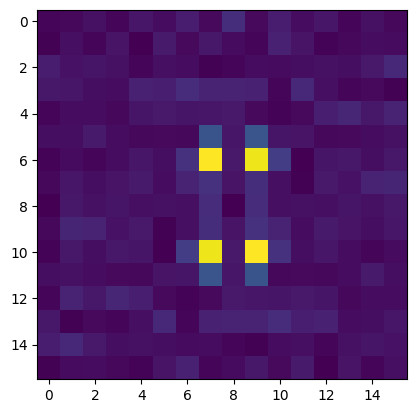

In [18]:
plt.imshow(np.abs(cyc + 1j*syc).reshape(16,16))

Also looks reasonable.

In [19]:
y1 = np.sin(1*1*np.pi*x[:,0])*np.sin(2*1*np.pi*x[:,1])
y2 = np.sin(4*1*np.pi*x[:,0])*np.sin(2*1*np.pi*x[:,1])
y3 = np.sin(2*1*np.pi*x[:,0])*np.sin(4*1*np.pi*x[:,1])
y4 = np.sin(3*1*np.pi*x[:,0])*np.sin(6*1*np.pi*x[:,1])
y5 = np.sin(4*1*np.pi*x[:,0])*np.sin(8*1*np.pi*x[:,1])

#yd = np.sin(2.8*1*np.pi*y1)*np.sin(5.3*1*np.pi*y2)
yd = np.sin(2*1*np.pi*y1)

# this seems very complicated, let's try something easier first
#yd = y1/5 + 0*y2/5 + y3/5 + y4/5 + y5/5
# this doesn't converge as well, maybe the above is better?

Text(0, 0.5, 'y')

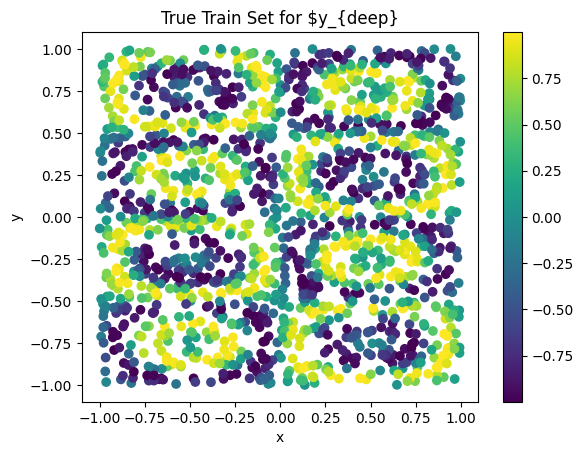

In [20]:
plt.scatter(x[:,0], x[:,1], c=yd)
plt.colorbar()
plt.title('True Train Set for $y_{deep}')
plt.xlabel('x')
plt.ylabel('y')

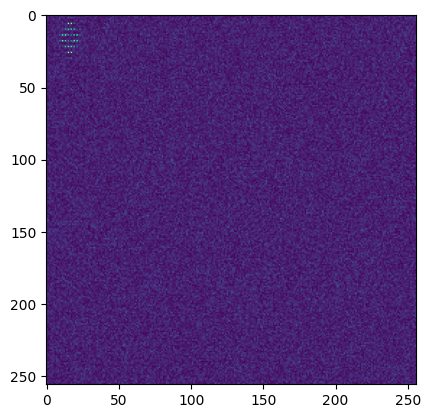

In [21]:
xc = (x*128).astype('int8')
#print(xc)
indexing='xy'
grid_info = np.array([[-16, 16,256] for j in np.arange(2)])
ff = [np.arange(grid_info[i,0], grid_info[i,1], (grid_info[i,1]-grid_info[i,0])/grid_info[i,2], dtype='int8') for i in np.arange(grid_info.shape[0])]
ff = np.meshgrid(*ff, indexing=indexing)
dd = len(ff)
NN = ff[0].size
fff = [np.reshape(xt,(NN,1)) for xt in ff]
f = np.hstack(np.array(fff))
#print(f)
xcf = np.matmul(x,f.T)
cc = np.cos(xcf*np.pi)
sc = np.sin(xcf*np.pi)
cyc = np.matmul(yd,cc)
syc = np.matmul(yd,sc)
cyc + 1j*syc
plt.imshow((np.abs(cyc + 1j*syc)).reshape(256,256))

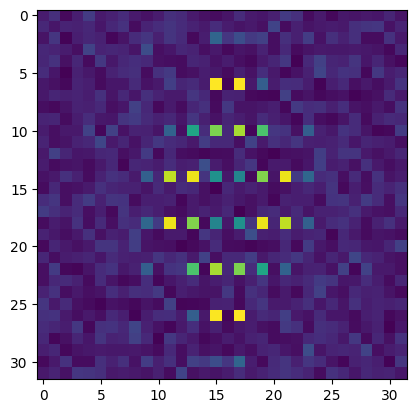

In [22]:
plt.imshow((np.abs(cyc + 1j*syc)).reshape(256,256)[:32,:32])

In [23]:
xt = (np.random.rand(mult*N*N).reshape(-1,2)*2-1)*span/2.0
y1t = np.sin(1*1*np.pi*xt[:,0])*np.sin(2*1*np.pi*xt[:,1])
y2t = np.sin(4*1*np.pi*xt[:,0])*np.sin(2*1*np.pi*xt[:,1])
y3t = np.sin(2*1*np.pi*xt[:,0])*np.sin(4*1*np.pi*xt[:,1])
y4t = np.sin(3*1*np.pi*xt[:,0])*np.sin(6*1*np.pi*xt[:,1])
y5t = np.sin(4*1*np.pi*xt[:,0])*np.sin(8*1*np.pi*xt[:,1])
#ydt = np.sin(2.8*1*np.pi*y1t)*np.sin(5.3*1*np.pi*y2t)
ydt = np.sin(2.*1*np.pi*y1t)

# this seems very complicated, let's try something easier first
#ydt = y1t/5 + 0*y2t/5 + y3t/5 + y4t/5 + y5t/5
# this doesn't converge as well, maybe the above is better?

In [ ]:
xtc = (xt*128).astype('int8')
#print(xc)
indexing='xy'
grid_info = np.array([[-16, 16,32] for j in np.arange(2)])
ff = [np.arange(grid_info[i,0], grid_info[i,1], (grid_info[i,1]-grid_info[i,0])/grid_info[i,2], dtype='int8') for i in np.arange(grid_info.shape[0])]
ff = np.meshgrid(*ff, indexing=indexing)
dd = len(ff)
NN = ff[0].size
fff = [np.reshape(xxt,(NN,1)) for xxt in ff]
f = np.hstack(np.array(fff))
#print(f)
xcf = np.matmul(xt,f.T)
cc = np.cos(xcf*np.pi)
sc = np.sin(xcf*np.pi)
cyc = np.matmul(ydt,cc)
syc = np.matmul(ydt,sc)
cyc + 1j*syc
plt.imshow((np.abs(cyc + 1j*syc)).reshape(32,32))

In [ ]:
plt.scatter(xt[:,0], xt[:,1], c=ydt)
plt.colorbar()
plt.title('True Test Set for $y_{deep}')
plt.xlabel('x')
plt.ylabel('y')

In [ ]:
MM=80
NN=80
print(2/3,1/3)
ss = [.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33]
bs = [-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66]
trues_wh = np.array([ss,bs])

In [ ]:
print(trues_wh.shape)

In [ ]:

class ShallowRegressor(nn.Module):
    def __init__(self):
        super(ShallowRegressor,self).__init__()
        self.fc1 = nn.Linear(2,MM)
        self.fc2 = nn.Linear(MM,NN)        
        self.fc3 = nn.Linear(NN,1)     
        self.fc1.weight = torch.nn.Parameter(torch.Tensor(trues_wh.T))
        #self.fc1.bias = torch.nn.Parameter(torch.Tensor(tv*zv))      
        #self.fc2.bias = torch.nn.Parameter(torch.Tensor(np.array([np.mean(y)])))
        #self.fc2.weight = torch.nn.Parameter(torch.Tensor((sne)*(sv).reshape(-1,1).T/MM))
      
        
    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))        
        x = self.fc3(x)
        return x

In [ ]:
model = ShallowRegressor()
criterion = nn.MSELoss()  # mean square error
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),lr=0.0001)

In [ ]:
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [ ]:
tensor_x = torch.Tensor(x) # transform to torch tensor
tensor_y = torch.Tensor(yd.reshape(-1,1))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')
model=model.to(device)
tensor_x=tensor_x.to(device)
tensor_y=tensor_y.to(device)
early_stopper = EarlyStopper(patience=8, min_delta=.001)
for epoch in range(40000):  # loop over the dataset multiple times


    # zero the parameter gradients
    optimizer.zero_grad()

    # forward + backward + optimize
    outputs = model(tensor_x)
    loss = criterion(outputs, tensor_y)
    loss.backward()
    optimizer.step()
    # print statistics
    with torch.no_grad(): 
        outputs = model(torch.Tensor(xt))
        vloss = criterion(outputs, torch.Tensor(ydt.reshape(-1,1)))    
    if epoch%500==0:
        print(f'[{epoch + 1}] loss: {loss.item():.3f} vloss: {vloss.item():.3f}')
    if early_stopper.early_stop(vloss):             
        break
print('Finished Training')

In [ ]:
print(tensor_x.shape)
ABS = 60
XX = np.linspace(-1,1,ABS,endpoint=False)
XXg = mt.grid_to_stack(np.meshgrid(XX,XX))
print(XXg.shape)

In [ ]:
model.eval()
YYg = model(torch.Tensor(XXg).to(device))

In [ ]:
y1g = np.sin(1*1*np.pi*XXg[:,0])*np.sin(2*1*np.pi*XXg[:,1])
y2g = np.sin(4*1*np.pi*XXg[:,0])*np.sin(2*1*np.pi*XXg[:,1])
y3g = np.sin(2*1*np.pi*XXg[:,0])*np.sin(4*1*np.pi*XXg[:,1])
y4g = np.sin(3*1*np.pi*XXg[:,0])*np.sin(6*1*np.pi*XXg[:,1])
y5g = np.sin(4*1*np.pi*XXg[:,0])*np.sin(8*1*np.pi*XXg[:,1])
#ydg = np.sin(2.8*1*np.pi*y1g)*np.sin(5.3*1*np.pi*y2g)
ydg = np.sin(2*1*np.pi*y1g)

# this seems very complicated, let's try something easier first
#ydg = y1g/5 + 0*y2g/5 + y3g/5 + y4g/5 + y5g/5
# this doesn't converge as well, maybe the above is better?

In [ ]:
plt.imshow((ydg).reshape(ABS,ABS),extent=[-1, 1, -1, 1])
plt.colorbar()

In [ ]:
#print(model.fc1.bias)
#print(model.fc1.weight)
print(model.fc1.weight.detach().numpy())
print(model.fc1.bias.detach().numpy())


In [ ]:
wh1, wn1 = bounds.nn_wnorm(model.fc1.weight.detach().numpy().T)
print(wh1.shape)
wh2, wn2 = bounds.nn_wnorm(model.fc2.weight.detach().numpy().T)
print(wh2.shape)

In [ ]:
print(model)
model_parameters = filter(lambda p: p.requires_grad, model.parameters())
params = sum([np.prod(p.size()) for p in model_parameters])
print(params)

In [ ]:
print(wh1.T)
print(wn1)
print((np.abs(np.abs(wh1.T[:,0])-0.33)<.01) )

In [ ]:
print(wh2)
print(wn2)

In [ ]:
plt.imshow((YYg.detach().numpy()).reshape(ABS,ABS),extent=[-1, 1, -1, 1])
plt.colorbar()

In [ ]:
plt.scatter(wh1.T[:,0], wh1.T[:,1])
#plt.scatter([4.1/(4.1+1.2),-4.1/(4.1+1.2),4.1/(4.1+1.2),-4.1/(4.1+1.2),2.1/(2.1+3.4),-2.1/(2.1+3.4),2.1/(2.1+3.4),-2.1/(2.1+3.4)],[1.2/(4.1+1.2),1.2/(4.1+1.2),-1.2/(4.1+1.2),-1.2/(4.1+1.2),3.4/(2.1+3.4),3.4/(2.1+3.4),-3.4/(2.1+3.4),-3.4/(2.1+3.4)])
plt.scatter([1/(1+2),-1/(1+2),1/(1+2),-1/(1+2)],[2/(1+2),2/(1+2),-2/(1+2),-2/(1+2)],marker='1')
plt.title('Hidden Weights in Layer 1')
plt.xlabel('f_x')
plt.ylabel('f_y')
print(2/(2+1))
print(1/(1+2))

In [ ]:
plt.hist((model.fc1.bias.detach().numpy()/wn1)[(np.abs(np.abs(wh1.T[:,0])-0.33)<.1) ])


In [ ]:
print(wh2.T[:,(np.abs(np.abs(wh1.T[:,0])-0.38)<.01)])
print(wh2.shape)
print(wh2.T[:,~(np.abs(np.abs(wh1.T[:,0])-0.38)<.01)])
print(wn2)